In [1]:
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings("ignore")

In [2]:
import torch

from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel,
)
from PycalcAct.trainer import Trainer

_ = torch.manual_seed(1234)


In [6]:
myPath = 'D:\\Ca2-Analysis_McGill\\dataExport\\'
HMRdata = 'D:\Ca2-Analysis_McGill\\dataExport\\validationHMR\\'
dataset = Dataset(
    csv_path=myPath+"legend.csv",
    csv_pos_path=myPath+"position.csv",  # Optional
    position_to_displacement=True
    # Convert the x, y position to a single displacement value (sqrt((x(t+1)-x(t))^2 + (y(t+1)-y(t))^2)
)
model = MixedFCTemporalModel(
    n_classes=dataset.n_classes,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
)

n_epochs = 750
trainer = Trainer(
    dataset, model, device="cuda"
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


In [7]:
trainer.summary(optimizer=False, model=True, data=True)

Model
Layer (type:depth-idx)                   Output Shape              Param #
MixedFCTemporalModel                     [10, 4]                   --
├─GRU: 1-1                               [10, 120, 64]             25,728
├─Sequential: 1-2                        [10, 64]                  --
│    └─Sequential: 2-1                   [10, 64]                  --
│    │    └─Linear: 3-1                  [10, 64]                  491,584
│    │    └─ReLU: 3-2                    [10, 64]                  --
│    │    └─Dropout1d: 3-3               [10, 64]                  --
│    └─Sequential: 2-2                   [10, 64]                  --
│    │    └─Linear: 3-4                  [10, 64]                  4,160
│    │    └─ReLU: 3-5                    [10, 64]                  --
│    │    └─Dropout1d: 3-6               [10, 64]                  --
├─Linear: 1-3                            [10, 4]                   260
Total params: 521,732
Trainable params: 521,732
Non-trainable para

,Total,N4,Q4,Q4H7,T4
Train,16084,6144,4790,2299,2851
Validation,4022,1536,1198,575,713
Test,5027,1920,1497,719,891
Total,25133,9600,7485,3593,4455


# Learning with Displacement encoding

╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.39 │                     39.88 │
│             2             │                      1.38 │                     42.99 │
│             3             │                      1.37 │                     43.06 │
│             4             │                      1.35 │                     45.43 │
│             5             │                      1.33 │                     46.44 │
│             9             │                      1.29 │                     46.84 │
│             10            │                      1.28 │                     47.49 │
│             12            │                      1.28 │                     47.84 │
│             13            │                      1.2

AttributeError: 'Trainer' object has no attribute 'save'

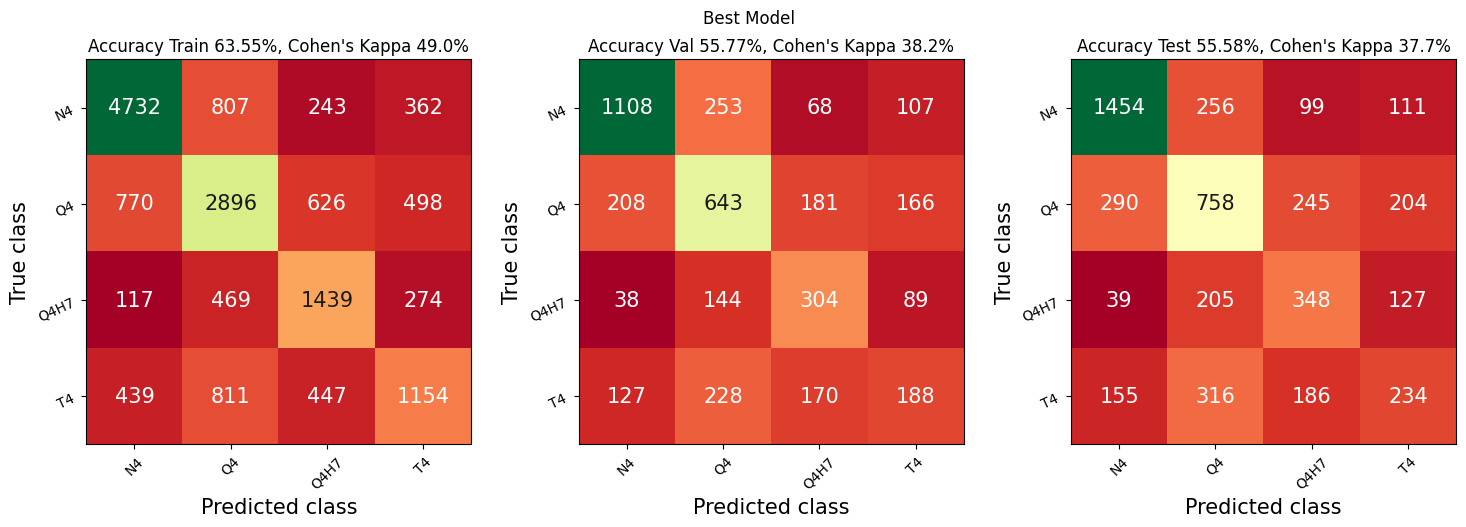

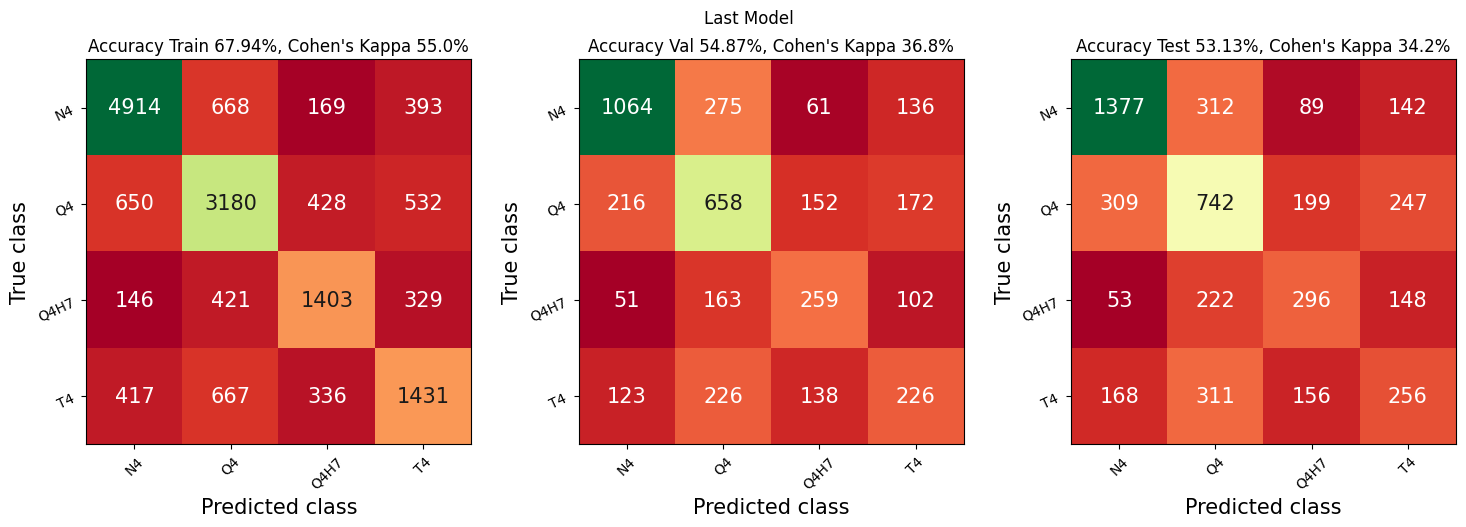

In [8]:
trainer.train(n_epochs)
trainer.test("best")  # Testing on the best model (in term of validation accuracy)
trainer.test("last")  # Testing on the last model

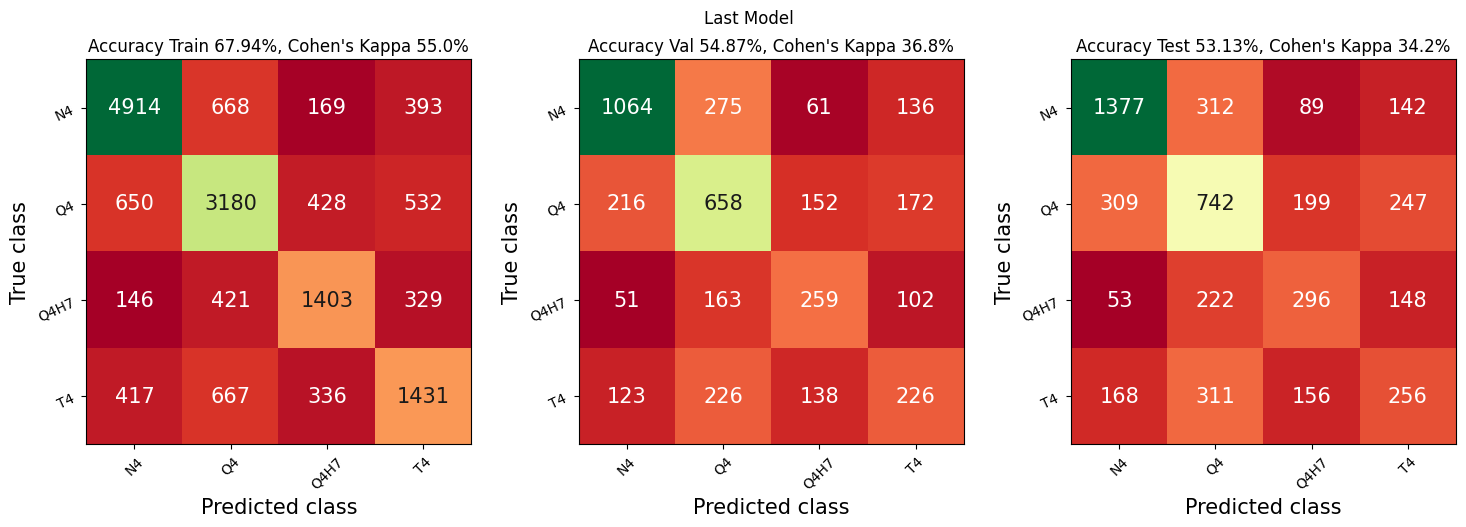

In [18]:
trainer.test("last")

In [9]:
datasetHMR = Dataset(
    csv_path=HMRdata+"legend.csv",
    csv_pos_path=HMRdata+"position.csv",  # Optional
    position_to_displacement=True,
    # Convert the x, y position to a single displacement value (sqrt((x(t+1)-x(t))^2 + (y(t+1)-y(t))^2)
)
datasetHMR.summarize()

Dataset summary: timepoints 120, features 2


,Total,N4,Q4,T4
Train,12509,4616,3918,3975
Validation,3128,1154,980,994
Test,3910,1443,1224,1243
Total,19547,7213,6122,6212


In [10]:
trainerHMR = Trainer(
    datasetHMR, trainer.model, device="cuda"
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


In [96]:
import matplotlib.pyplot as plt
# fig, axs = plt.subplots(1, 3, figsize=(18, 5))
# trainer.model.load_state_dict(trainer._best_state_dict)
# fig.suptitle("Last Model")

callbacks = (
            trainerHMR.dataset.train_batch,
            trainerHMR.dataset.val_batch,
            trainerHMR.dataset.test_batch,
        )

for i, (name, callable) in enumerate(zip(["Train", "Val", "Test"], callbacks)):
            x, y = callable(True, to_cuda=True)
            print(y)

            trainerHMR.model.eval()
            trainerHMR.metrics.reset()
            trainerHMR.confmat.reset()


            with torch.no_grad():
                y_pred = trainerHMR.model(x)
                y_pred_mod = torch.cat((y_pred, torch.tensor([[0,0,0,0]], device='cuda')))
                y_mod = torch.cat((y, torch.tensor([3], device='cuda')))
                loss = trainerHMR.criterion(y_pred_mod, y_mod.long())

tensor([2, 0, 2,  ..., 1, 2, 2], device='cuda:0', dtype=torch.int32)


RuntimeError: weight tensor should be defined either for all 4 classes or no classes but got weight tensor of shape: [3]